In [1]:
# implimenting the kaggle commands
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d hemantsoni042/celebrity-images-for-face-recognition

Dataset URL: https://www.kaggle.com/datasets/hemantsoni042/celebrity-images-for-face-recognition
License(s): unknown
100% 1.71G/1.71G [01:40<00:00, 18.3MB/s]



In [3]:
!unzip -q celebrity-images-for-face-recognition.zip -d celebrity

In [4]:
import os
root_path = '/content/celebrity/celebrities_images'

In [5]:
# total celebrities we have and what are those
celebrities = os.listdir(root_path)
print(len(celebrities))
print(celebrities)

98
['Prabhas', 'Jennifer Lawrence', 'Aamir Khan', 'Sushant Singh Rajput', 'Rajkummar Rao', 'John Abraham', 'Benedict Cumberbatch', 'Abhay Deol', 'Prachi Desai', 'Ranbir Kapoor', 'Denzel Washington', 'Priyanka Chopra', 'Salman Khan', 'Elizabeth Olsen', 'Ayushmann Khurrana', 'Irrfan Khan', 'Paresh Rawal', 'Randeep Hooda', 'Deepika Padukone', 'Manoj Bajpayee', 'Megan Fox', 'Anushka Sharma', 'Hrithik Roshan', 'Juhi Chawla', 'Madhuri Dixit', 'Sonam Kapoor', 'Ajay Devgn', 'Pooja Hegde', 'Arjun Kapoor', 'Sara Ali Khan', 'Mark Ruffalo', 'Bipashu Basu', 'Bhumi Padnekar', 'Nicole Kidman', 'Hugh Jackman', 'Chris Evans', 'Sidharth Malhotra', 'Paul Rudd', 'IIeana DCruz', 'Sanjay Dutt', 'Amitabh Bachchan', 'Emraan Hashmi', 'Mrunal Thakur', 'Narendra Modi', 'Akshay Kumar', 'Karisma Kapoor', 'Arjun Rampal', 'Akshaye Khanna', 'Saif Ali Khan', 'Brad Pitt', 'Aishwarya Rai', 'Katrina Kaif', 'Johnny Depp', 'Leonardo DiCaprio', 'Bobby Deol', 'Shruti Haasan', 'Riteish Deshmukh', 'Parineeti Chopra', 'Josh Bro

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

sardha_kapoor = os.listdir(root_path + '/Shraddha Kapoor')
print(len(sardha_kapoor))

for i in range(10):
  idx = random.randint(0, len(sardha_kapoor)-1)
  img = mpimg.imread(root_path + '/Shraddha Kapoor/' + sardha_kapoor[idx])
  plt.imshow(img)
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# creating the data set for sardha kapoor and non sardha we will use the data agumentation + using 10 images of
# other celibrities
# we wil use pre trianed resnet + fine tunet o identify about sardha or not

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout,BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import Sequential

In [9]:
sarddha_data = []
sarddha_label = []

for img in sardha_kapoor:
  sarddha_data.append(mpimg.imread(root_path + '/Shraddha Kapoor/' + img))
  sarddha_label.append(1)

In [11]:
data = []
label = []

image_extensions = ('.jpg', '.jpeg', '.png', '.gif')

for celebrity in os.listdir('/content/celebrity/celebrities_images'):
  if celebrity == 'Shraddha Kapoor':
    continue
  all_celebrity_files = os.listdir(root_path + '/' + celebrity)
  celebrity_images = [f for f in all_celebrity_files if f.lower().endswith(image_extensions)]

  print(f'{celebrity}:{len(celebrity_images)}')

  if not celebrity_images:
      print(f"Warning: No valid image files found for {celebrity}. Skipping.")
      continue

  for i in range(3):
    # random 2
    idx = random.randint(0, len(celebrity_images)-1)
    img = celebrity_images[idx]
    try:
        data.append(mpimg.imread(root_path + '/' + celebrity + '/' + img))
        label.append(0)
    except Exception as e:
        print(f"Error reading image {img} for {celebrity}: {e}")

Prabhas:245
Jennifer Lawrence:84
Aamir Khan:191
Sushant Singh Rajput:187
Rajkummar Rao:146
John Abraham:163
Benedict Cumberbatch:46
Abhay Deol:127
Prachi Desai:155
Ranbir Kapoor:167
Denzel Washington:92
Priyanka Chopra:180
Salman Khan:158
Elizabeth Olsen:45
Ayushmann Khurrana:143
Irrfan Khan:137
Paresh Rawal:107
Randeep Hooda:135
Deepika Padukone:227
Manoj Bajpayee:145
Megan Fox:87
Anushka Sharma:209
Hrithik Roshan:149
Juhi Chawla:138
Madhuri Dixit:181
Sonam Kapoor:46
Ajay Devgn:173
Pooja Hegde:186
Arjun Kapoor:163
Sara Ali Khan:152
Mark Ruffalo:49
Bipashu Basu:169
Bhumi Padnekar:132
Nicole Kidman:90
Hugh Jackman:100
Chris Evans:98
Sidharth Malhotra:45
Paul Rudd:48
IIeana DCruz:179
Sanjay Dutt:119
Amitabh Bachchan:195
Emraan Hashmi:140
Mrunal Thakur:160
Narendra Modi:58
Akshay Kumar:169
Karisma Kapoor:169
Arjun Rampal:117
Akshaye Khanna:86
Saif Ali Khan:130
Brad Pitt:100
Aishwarya Rai:218
Katrina Kaif:206
Johnny Depp:100
Leonardo DiCaprio:91
Bobby Deol:111
Shruti Haasan:52
Riteish Desh

In [12]:
len(data)

291

In [13]:
# data agumentation on sarddha array
import cv2

IMG_SIZE = (224, 224)

# 1. Resize images and convert your lists to uniform numpy arrays
resized_shraddha_images = [cv2.resize(img, IMG_SIZE) for img in sarddha_data]

X_shraddha = np.array(resized_shraddha_images)      # Shape: (53, height, width, channels)
y_shraddha = np.array(sarddha_label)     # Shape: (53,)

# 2. Set up the Data Augmentation Generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 3. Create lists to hold the augmented data
augmented_images = list(X_shraddha)
augmented_labels = list(y_shraddha)

# Target number of total images
target_count = 291
needed_images = target_count - len(X_shraddha)

# 4. Generate exactly the remaining number of images needed
# ImageDataGenerator flow requires a 4D array, so we pass X_shraddha
batch_size = 1
generator = datagen.flow(X_shraddha, y_shraddha, batch_size=batch_size)

for i in range(needed_images):
    # Grab the next augmented image batch
    x_batch, y_batch = next(generator)

    augmented_images.append(x_batch[0].astype(np.uint8))
    augmented_labels.append(int(y_batch[0]))

# 5. Convert back to final numpy arrays
sarddha_data_augmented = np.array(augmented_images)
sarddha_label_augmented = np.array(augmented_labels)

# Verify the final shapes
print("Augmented Data Shape:", sarddha_data_augmented.shape)
print("Augmented Label Shape:", sarddha_label_augmented.shape)

Augmented Data Shape: (291, 224, 224, 3)
Augmented Label Shape: (291,)


In [14]:
# rersizing non sarddha
resized_non_shraddha = []
for img in data:
    if len(img.shape) == 2: # Grayscale
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4: # RGBA
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    resized_non_shraddha.append(cv2.resize(img, (224, 224)))
X_non_shraddha = np.array(resized_non_shraddha)
y_non_shraddha = np.array(label)

In [15]:
X_non_shraddha.shape

(291, 224, 224, 3)

In [211]:
# concating the two non sarddha and sarddha kappor
X = np.concatenate((sarddha_data_augmented, X_non_shraddha), axis=0)
y = np.concatenate((sarddha_label_augmented, y_non_shraddha),axis=0)

In [134]:
# from tensorflow.keras.applications.resnet50 import preprocess_input
# X = preprocess_input(X)

In [212]:
y.shape

(582,)

In [213]:
# shuffline the x and y and then sending to model prediction
permutation = np.random.permutation(len(X))

# Shuffle both arrays using the same indices
X = X[permutation]
y = y[permutation]

In [214]:
X.shape , y.shape

((582, 224, 224, 3), (582,))

In [189]:
y

array([0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,

In [215]:
# resnet modeling
model = Sequential()
model.add(ResNet50(include_top=False, pooling='avg', weights='imagenet'))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.layers[0].trainable = False

In [216]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [217]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,155,265 (92.15 MB)

 Trainable params: 566,657 (2.16 MB)

 Non-trainable params: 23,588,608 (89.98 MB)

In [218]:
# Preprocess a fresh copy right before fitting so your original X stays clean
X_preprocessed = preprocess_input(X.copy())

history = model.fit(
    X_preprocessed,
    y,
    epochs=8,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 558ms/step - accuracy: 0.6817 - loss: 0.5983 - val_accuracy: 0.7607 - val_loss: 0.4703
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8602 - loss: 0.3126 - val_accuracy: 0.8632 - val_loss: 0.2561
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8882 - loss: 0.2692 - val_accuracy: 0.8974 - val_loss: 0.2168
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9376 - loss: 0.1782 - val_accuracy: 0.8803 - val_loss: 0.2569
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9226 - loss: 0.2078 - val_accuracy: 0.8974 - val_loss: 0.2293
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9419 - loss: 0.1661 - val_accuracy: 0.9316 - val_loss: 0.1896
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9570 - loss: 0.1319 - val_accuracy: 0.9231 - val_loss: 0.1831
Epoch 8/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9419 - loss: 0.1442 - val_accuracy: 0.9402 - val_los

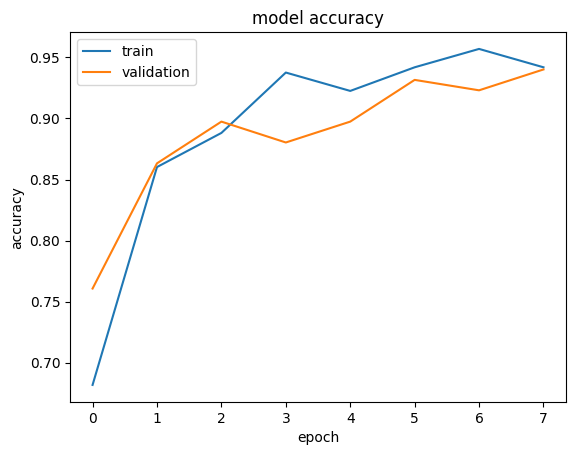

In [219]:
# interpreting the results
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

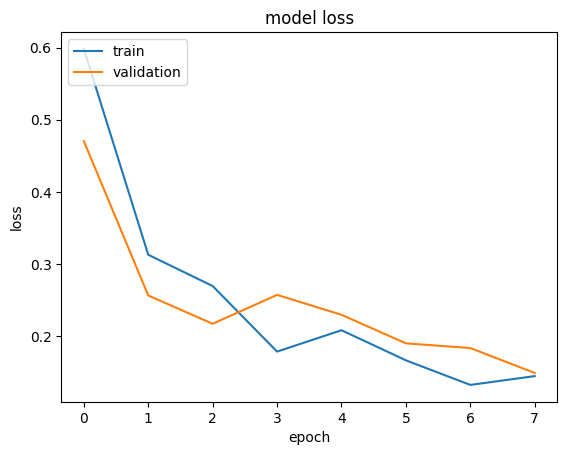

In [220]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 391ms/step


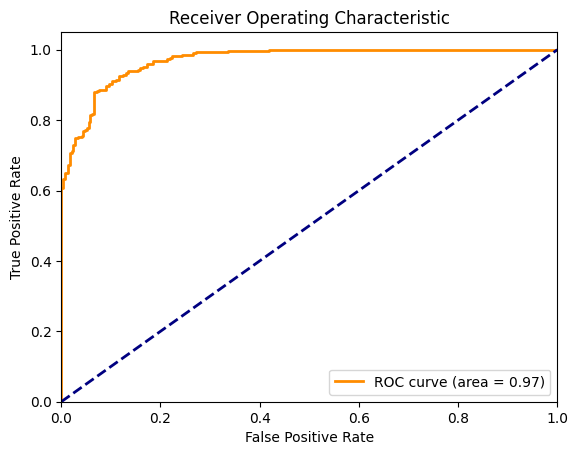

In [221]:
# roc auc graph
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = model.predict(X).ravel()

fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

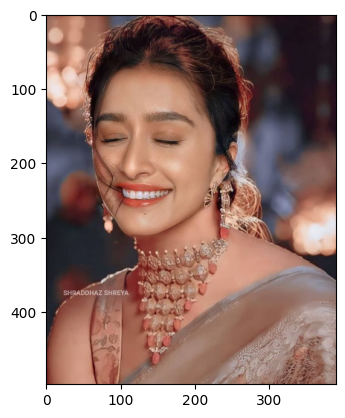

In [242]:
plt.imshow(mpimg.imread('/content/img10.png'))

In [252]:
# model testing

gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
optimal_threshold = thresholds[ix]

def test_with_image(image_path):
    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if len(img.shape) == 2:  # Grayscale
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:  # RGBA
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)

    img = cv2.resize(img, (224, 224))
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img.astype('float32'))

    prediction = model.predict(img)

    if prediction[0][0] > optimal_threshold:
        print("Shraddha Kapoor")
        print(prediction[0][0])
    else:
        print("Not Shraddha Kapoor")
        print(prediction[0][0])

print(f"Optimal Threshold: {optimal_threshold:.4f}")
test_with_image('/content/img10.png')

Optimal Threshold: 0.1386
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Shraddha Kapoor
0.18352269
